In [5]:
import numpy as np
import cv2 as cv

# Criar uma imagem em branco (300x300 pixels)
image = np.zeros((300, 300, 3), dtype=np.uint8)

# Definir a cor laranja média em BGR (OpenCV usa BGR ao invés de RGB)
# Converter de RGB (252, 134, 25) para BGR (25, 134, 252)
orange = (25, 134, 252)

# Preencher a imagem com a cor laranja
image[:] = orange
hsv_img = cv.cvtColor(image, cv.COLOR_BGR2HSV)

# Mostrar a imagem
cv.imshow('Quadrado Laranja', image)
cv.waitKey(0)
cv.destroyAllWindows()

In [7]:
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", image)
cv.imshow("Inspect Image", hsv_img) # OpenCV >> HSV values: 14, 230, 252
cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

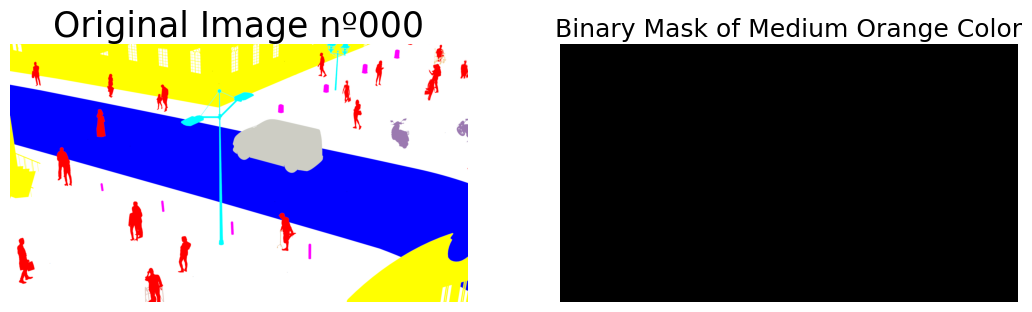

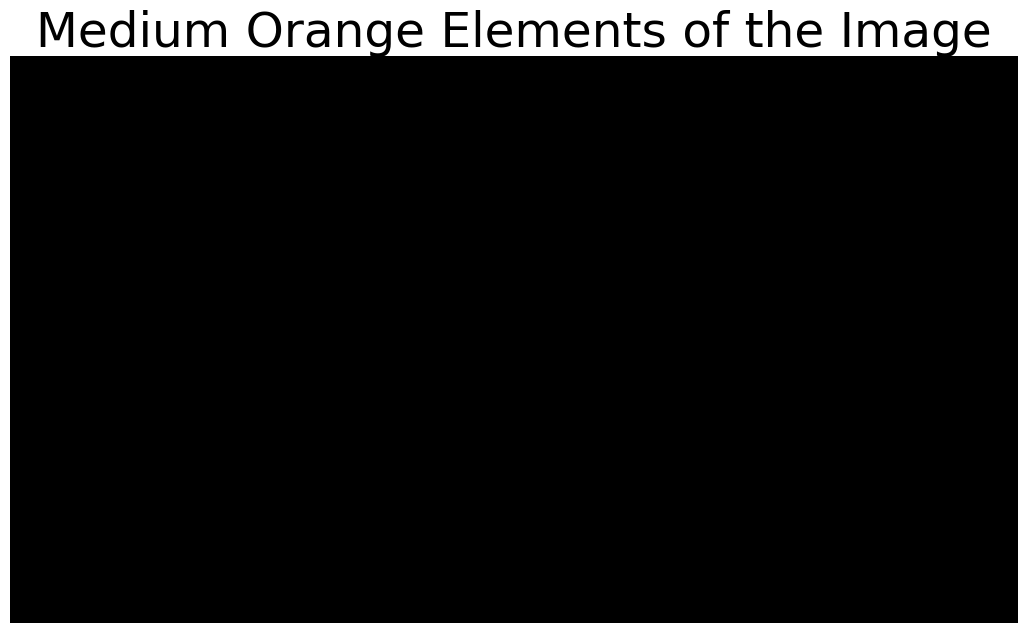

In [9]:
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/home/renato/Work/pucpr_pibic_semantic_segmentation/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### CONSTRUÇÃO DE EXEMPLO DA COR LARANJA MÉDIO ###

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# Define limits for Medium Orange Color >> HSV (H:14, S:230, V:252) to (H:14, S:230, V:252)
lower_bound = np.array([14, 230, 252]) # Hue, Saturation, Value
upper_bound = np.array([14, 230, 252]) # Hue, Saturation, Value

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Medium Orange Color",fontdict={'fontsize': 18})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Medium Orange Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')